In [1]:
import pandas as pd
import ast

In [2]:
df = pd.read_csv("/usr/homes/sgl57/NeuS/NeuS-QA/experiment_results/nsvs/longvideobench/InternVL2-8B/dynamic_1_experiment_5_accurate_runtime_window_3/metric_data.csv")
# rt-neus /usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/InternVL2-8B/rt-neus/experiment_6/metric_data.csv
# naive /usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs/longvideobench/InternVL2-8B/dynamic_1_experiment_4_accurate_runtime_window_3/metric_data.csv
# display(df)

In [3]:
pd.set_option('display.max_columns', None)
df.describe()

,video_IO_time,automaton_set_up_time,num_frame_windows,num_model_checks,num_vlm_detections,PULS_time,num_propositions,Target_ID_time,NeuS_time,completion_time,cropping_video,foi_count,pct_foi_out_of_full,frame_count,duration_group,starting_timestamp_for_subtitles,duration,view_count
count,307.000000,303.000000,303.000000,303.000000,303.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,3.070000e+02
mean,86.848350,0.000376,265.178218,29.211221,925.240924,1.261906,3.309446,1.443876,651.058753,653.764538,22.807741,6955.648208,0.463713,21652.439739,1949.120521,65.465798,792.478664,4.815350e+05
std,90.786431,0.000374,251.571092,67.743636,1068.960582,0.573384,1.880066,0.375226,826.338904,826.570747,44.558028,13745.636985,0.438256,20700.878806,1660.155677,246.204551,753.388041,1.350660e+06
min,0.237282,0.000063,3.000000,0.000000,0.000000,0.503504,0.000000,0.778557,0.499411,3.674719,0.380067,72.000000,0.003000,193.000000,15.000000,0.000000,7.980000,7.900000e+01
25%,10.830972,0.000275,21.000000,1.000000,32.000000,0.924434,2.000000,1.183412,47.556026,50.310470,2.046033,389.000000,0.040500,1819.500000,60.000000,0.000000,60.500000,1.782750e+04
50%,56.452494,0.000337,201.000000,4.000000,591.000000,1.121719,3.000000,1.361628,311.595808,313.949472,5.010137,1174.000000,0.252000,17984.000000,600.000000,0.000000,600.070000,8.567700e+04
75%,140.191266,0.000393,392.000000,19.500000,1476.000000,1.429732,4.000000,1.605951,1066.041634,1068.863661,15.540174,4034.500000,1.000000,31528.000000,3600.000000,0.000000,1189.360000,3.203350e+05
max,460.499559,0.006126,1162.000000,494.000000,6561.000000,6.195829,10.000000,3.312978,6169.574540,6172.339874,252.757342,89784.000000,1.000000,89784.000000,3600.000000,2871.000000,3485.120000,1.128352e+07


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   video_IO_time                     307 non-null    float64
 1   automaton_set_up_time             305 non-null    float64
 2   num_frame_windows                 305 non-null    float64
 3   per_proposition_detection_time    285 non-null    object 
 4   per_frame_window_detection_time   305 non-null    object 
 5   model_checks_time                 254 non-null    object 
 6   num_model_checks                  305 non-null    float64
 7   num_vlm_detections                305 non-null    float64
 8   PULS_time                         307 non-null    float64
 9   num_propositions                  307 non-null    int64  
 10  Target_ID_time                    307 non-null    float64
 11  NeuS_time                         307 non-null    float64
 12  completi

In [4]:
df_neus_qa = pd.read_csv("/usr/homes/sgl57/NeuS/NeuS-QA/experiment_results/nsvs/longvideobench/InternVL2-8B/dynamic_1_experiment_5_accurate_runtime_window_3/metric_data.csv")
df.describe()

,video_IO_time,automaton_set_up_time,num_frame_windows,num_model_checks,num_vlm_detections,PULS_time,num_propositions,Target_ID_time,NeuS_time,completion_time,cropping_video,foi_count,pct_foi_out_of_full,frame_count,duration_group,starting_timestamp_for_subtitles,duration,view_count
count,307.000000,303.000000,303.000000,303.000000,303.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,3.070000e+02
mean,86.848350,0.000376,265.178218,29.211221,925.240924,1.261906,3.309446,1.443876,651.058753,653.764538,22.807741,6955.648208,0.463713,21652.439739,1949.120521,65.465798,792.478664,4.815350e+05
std,90.786431,0.000374,251.571092,67.743636,1068.960582,0.573384,1.880066,0.375226,826.338904,826.570747,44.558028,13745.636985,0.438256,20700.878806,1660.155677,246.204551,753.388041,1.350660e+06
min,0.237282,0.000063,3.000000,0.000000,0.000000,0.503504,0.000000,0.778557,0.499411,3.674719,0.380067,72.000000,0.003000,193.000000,15.000000,0.000000,7.980000,7.900000e+01
25%,10.830972,0.000275,21.000000,1.000000,32.000000,0.924434,2.000000,1.183412,47.556026,50.310470,2.046033,389.000000,0.040500,1819.500000,60.000000,0.000000,60.500000,1.782750e+04
50%,56.452494,0.000337,201.000000,4.000000,591.000000,1.121719,3.000000,1.361628,311.595808,313.949472,5.010137,1174.000000,0.252000,17984.000000,600.000000,0.000000,600.070000,8.567700e+04
75%,140.191266,0.000393,392.000000,19.500000,1476.000000,1.429732,4.000000,1.605951,1066.041634,1068.863661,15.540174,4034.500000,1.000000,31528.000000,3600.000000,0.000000,1189.360000,3.203350e+05
max,460.499559,0.006126,1162.000000,494.000000,6561.000000,6.195829,10.000000,3.312978,6169.574540,6172.339874,252.757342,89784.000000,1.000000,89784.000000,3600.000000,2871.000000,3485.120000,1.128352e+07


In [8]:
df_experiment_4 = pd.read_csv("/usr/homes/sgl57/NeuS/NeuS-QA/experiment_results/le-neus/lvb/experiment_5/metric_data.csv")
pd.set_option('display.max_columns', None)
df_experiment_4.describe()

,PULS_time,num_propositions,Target_ID_time,NeuS_time,completion_time,video_IO_time,final_num_frames_sampled,pct_final_num_from_uniform,automaton_set_up_time,num_frame_windows,num_model_checks,num_vlm_detections,duration_group,starting_timestamp_for_subtitles,duration,view_count,fps,frame_count,expected_uniform_count,initial_num_frames_sampled,stage1_num_frames_retained,pct_stage1_from_uniform,stage2_num_frames_retained,pct_stage2_from_stage1,pct_stage2_from_uniform
count,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,307.000000,294.000000,294.000000,294.000000,294.0,307.000000,307.000000,307.000000,3.070000e+02,307.000000,307.000000,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000
mean,1.947956,4.013029,1.207793,40.497097,43.652883,25.286526,154.459283,0.424011,0.000422,57.054422,31.292517,0.0,1949.120521,65.465798,792.478664,4.815350e+05,27.790844,21652.439739,1027.938053,1054.044248,275.380531,0.311832,190.716814,0.660451,0.202919
std,0.666822,2.111243,0.443558,30.694689,30.791391,20.520899,106.237314,0.382844,0.000191,38.381289,31.778932,0.0,1660.155677,246.204551,753.388041,1.350660e+06,4.668689,20700.878806,503.455240,510.668997,93.797969,0.135263,99.484937,0.195239,0.100931
min,0.816232,1.000000,0.598316,0.483210,3.143283,0.103095,11.000000,0.012700,0.000168,5.000000,0.000000,0.0,15.000000,0.000000,7.980000,7.900000e+01,23.833000,193.000000,287.000000,300.000000,31.000000,0.032300,11.000000,0.130100,0.012700
25%,1.527327,2.000000,0.900895,11.118636,14.924402,1.012015,55.500000,0.154250,0.000323,20.000000,6.000000,0.0,60.000000,0.000000,60.500000,1.782750e+04,23.980000,1819.500000,590.000000,610.000000,209.250000,0.221025,104.000000,0.527425,0.127125
50%,1.895615,4.000000,1.105756,40.579295,43.345152,26.333441,130.000000,0.244900,0.000384,52.000000,19.000000,0.0,600.000000,0.000000,600.070000,8.567700e+04,29.970000,17984.000000,1000.000000,1040.000000,302.000000,0.296100,196.000000,0.704450,0.200500
75%,2.259381,5.000000,1.364094,62.127207,65.320587,38.550620,243.500000,1.000000,0.000455,90.000000,50.750000,0.0,3600.000000,0.000000,1189.360000,3.203350e+05,30.000000,31528.000000,1260.000000,1297.750000,340.750000,0.400175,275.000000,0.824500,0.261275
max,6.428082,12.000000,4.864100,142.689671,146.573483,77.725879,453.000000,1.130400,0.001410,162.000000,162.000000,0.0,3600.000000,2871.000000,3485.120000,1.128352e+07,60.000000,89784.000000,2613.000000,2641.000000,529.000000,0.662000,453.000000,0.938600,0.531600


In [9]:
df_experiment_new = pd.read_csv("/usr/homes/sgl57/NeuS/NeuS-QA/experiment_results/rt-neus/lvb/experiment_1/metric_data.csv")
pd.set_option('display.max_columns', None)
df_experiment_new.describe()

,PULS_time,num_propositions,Target_ID_time,NeuS_time,completion_time,video_IO_time,expected_uniform_count,initial_num_frames_sampled,stage1_num_frames_retained,pct_stage1_from_uniform,stage2_num_frames_retained,pct_stage2_from_stage1,pct_stage2_from_uniform,final_num_frames_sampled,pct_final_num_from_uniform,automaton_set_up_time,num_frame_windows,num_model_checks,num_vlm_detections,duration_group,starting_timestamp_for_subtitles,duration,view_count,fps,frame_count
count,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,304.000000,304.000000,302.000000,302.000000,302.000000,302.0,304.000000,304.000000,304.000000,3.040000e+02,304.000000,304.000000
mean,1.608886,3.970395,0.949430,34.964935,37.523256,25.944072,774.511551,794.310231,220.739274,0.448755,150.333333,0.609170,0.244254,150.194079,0.246740,0.000284,55.377483,15.976821,0.0,1944.621711,64.111842,793.406645,4.780028e+05,27.769339,21659.542763
std,0.942137,2.097251,0.635502,27.478468,27.563294,21.171250,610.338262,622.178651,129.600333,0.264792,113.962921,0.231671,0.138688,113.800612,0.145085,0.000152,41.058623,24.090833,0.0,1659.231582,245.388035,755.432012,1.355785e+06,4.686682,20750.083545
min,0.725603,1.000000,0.559280,0.797364,2.376425,0.612254,20.000000,21.000000,8.000000,0.013300,2.000000,0.075000,0.013300,2.000000,0.013300,0.000065,1.000000,0.000000,0.0,15.000000,0.000000,7.980000,7.900000e+01,23.833000,193.000000
25%,1.233650,2.000000,0.752903,5.132407,8.046415,3.609785,117.000000,120.000000,58.000000,0.254900,30.000000,0.452000,0.154450,30.000000,0.154575,0.000185,12.000000,2.000000,0.0,60.000000,0.000000,60.565000,1.680000e+04,23.980000,1819.750000
50%,1.466081,4.000000,0.850485,35.054640,37.974640,25.192968,687.000000,723.000000,258.000000,0.356900,140.000000,0.641100,0.218100,139.500000,0.218250,0.000262,53.000000,5.000000,0.0,600.000000,0.000000,600.070000,8.567700e+04,29.970000,17984.000000
75%,1.723475,5.000000,1.007703,53.365256,57.017926,38.126504,1189.000000,1198.000000,323.500000,0.559550,248.500000,0.807050,0.293550,248.250000,0.293600,0.000357,92.750000,17.000000,0.0,3600.000000,0.000000,1189.360000,3.194830e+05,30.000000,31528.000000
max,12.008598,12.000000,8.377500,118.538019,121.429520,91.610116,2613.000000,2641.000000,502.000000,1.000000,438.000000,1.000000,0.826100,438.000000,1.000000,0.001058,156.000000,155.000000,0.0,3600.000000,2871.000000,3485.120000,1.128352e+07,60.000000,89784.000000


In [10]:
df_experiment_new_2 = pd.read_csv("/usr/homes/sgl57/NeuS/NeuS-QA/experiment_results/rt-neus/lvb/experiment_2/metric_data.csv")
pd.set_option('display.max_columns', None)
df_experiment_new_2.describe()

,PULS_time,num_propositions,Target_ID_time,NeuS_time,completion_time,video_IO_time,expected_uniform_count,initial_num_frames_sampled,stage1_num_frames_retained,pct_stage1_from_uniform,stage2_num_frames_retained,pct_stage2_from_stage1,pct_stage2_from_uniform,final_num_frames_sampled,pct_final_num_from_uniform,automaton_set_up_time,num_frame_windows,num_model_checks,num_vlm_detections,duration_group,starting_timestamp_for_subtitles,duration,view_count,fps,frame_count
count,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,304.000000,304.000000,302.000000,302.000000,302.000000,302.0,304.000000,304.000000,304.000000,3.040000e+02,304.000000,304.000000
mean,1.595990,3.986842,0.936242,37.977151,40.509387,28.732415,774.511551,794.310231,221.488449,0.449908,150.471947,0.607365,0.243357,150.332237,0.245846,0.000324,54.725166,15.990066,0.0,1944.621711,64.111842,793.406645,4.780028e+05,27.769339,21659.542763
std,1.577928,2.085584,0.652692,29.202701,29.258836,22.751157,610.338262,622.178651,129.746387,0.265290,113.969055,0.231630,0.137125,113.806904,0.143612,0.000182,40.983352,24.294905,0.0,1659.231582,245.388035,755.432012,1.355785e+06,4.686682,20750.083545
min,0.741283,1.000000,0.560193,0.830775,2.497022,0.665000,20.000000,21.000000,7.000000,0.013300,2.000000,0.075000,0.013300,2.000000,0.013300,0.000068,1.000000,0.000000,0.0,15.000000,0.000000,7.980000,7.900000e+01,23.833000,193.000000
25%,1.207286,2.000000,0.734386,5.620995,8.130767,3.638397,117.000000,120.000000,61.000000,0.255300,30.000000,0.452000,0.154700,30.000000,0.154700,0.000219,10.250000,2.000000,0.0,60.000000,0.000000,60.565000,1.680000e+04,23.980000,1819.750000
50%,1.404445,4.000000,0.831946,38.081433,40.683708,29.603791,687.000000,723.000000,258.000000,0.357100,142.000000,0.638700,0.218400,141.500000,0.218600,0.000295,52.500000,5.000000,0.0,600.000000,0.000000,600.070000,8.567700e+04,29.970000,17984.000000
75%,1.685874,5.000000,0.968534,59.980933,62.621763,43.255186,1189.000000,1198.000000,322.000000,0.557450,247.500000,0.798850,0.289850,247.250000,0.291500,0.000383,91.000000,17.000000,0.0,3600.000000,0.000000,1189.360000,3.194830e+05,30.000000,31528.000000
max,21.489479,12.000000,10.928700,130.268534,132.430101,94.941906,2613.000000,2641.000000,502.000000,1.000000,438.000000,1.000000,0.826100,438.000000,1.000000,0.001399,156.000000,155.000000,0.0,3600.000000,2871.000000,3485.120000,1.128352e+07,60.000000,89784.000000


In [5]:
import pandas as pd
import ast
import numpy as np
def calculate_foi_metrics(row):
    foi = row.get("frames_of_interest", [])
    frame_count = row.get("frame_count", 1)
    # is_naive could be a column or determined by the structure of foi
    if isinstance(foi, str):
        try: foi = ast.literal_eval(foi)
        except: return np.nan
    
    total_foi = 0

    if not isinstance(foi[0], (list, tuple)):
        if foi == [-1]:
                total_foi = frame_count
        else:
            total_foi = foi[1] - foi[0]
            if total_foi == 0:
                print(f"FOI: {foi}")
                total_foi = frame_count
    else:
        # Multi-segment logic
        for segment in foi:
            if segment == -1:
                total_foi = frame_count
                break # If one segment is the whole video, we can stop
            elif isinstance(segment, (list, tuple)) and len(segment) >= 2:
                total_foi += (segment[1] - segment[0])
    
    # Avoid division by zero
    # if total_foi <= 0:
    #     total_foi = 1
        
    # Using your specific math: frame_count / total_foi
    pct_foi = round(total_foi / frame_count, 4)
    
    return pd.Series([total_foi, pct_foi], index=['foi_count', 'pct_foi_out_of_full'])


In [6]:
import pandas as pd
import numpy as np
import ast

def build_final_summary(df):
    # 1. First, create the new columns so they exist in df.columns
    df[["foi_count", "pct_foi_out_of_full"]] = df.apply(calculate_foi_metrics, axis=1)
    # 2. Average the list-based columns
    list_columns = ["per_frame_window_detection_time", "model_checks_time"]
    def average_list(cell):
        if isinstance(cell, str):
            try: cell = ast.literal_eval(cell)
            except: return np.nan
        if isinstance(cell, list) and len(cell) > 0:
            return np.mean(cell)
        elif isinstance(cell, (int, float, np.number)):
            return cell
        return np.nan

    for col in list_columns:
        if col in df.columns:
            df[col] = df[col].apply(average_list)

    # 3. Define the Raw Metrics List (removed duplicates manually here too)
    raw_metrics = [
        "completion_time", "PULS_time", "Target_ID_time", "NeuS_time", 
        "frame_count", "num_propositions", "num_model_checks", 
        "num_vlm_detections", "video_IO_time", "automaton_set_up_time", 
        "expected_uniform_count", "initial_num_frames_sampled",
        "stage1_num_frames_retained", "pct_stage1_from_uniform",
        "stage2_num_frames_retained", "pct_stage2_from_stage1",
        "pct_stage2_from_uniform", "final_num_frames_sampled",
        "pct_final_num_from_uniform", "num_frame_windows",
        "foi_count", "pct_foi_out_of_full", 
        "per_frame_window_detection_time", "model_checks_time"
    ]

    # 4. Filter for existence and REMOVE DUPLICATES
    metrics = []
    for m in raw_metrics:
        if m in df.columns and m not in metrics:
            metrics.append(m)

    # 5. Ensure numeric types for aggregation
    for col in metrics:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 6. Categorize
    bins = [0, 15, 60, 600, 3600]
    labels = ["15", "60", "600", "3600"]
    df['category'] = pd.cut(df['duration_group'], bins=bins, labels=labels)

    # 7. Aggregate
    categorical_report = df.groupby('category', observed=False)[metrics].mean()
    global_report = df[metrics].mean().to_frame().T
    global_report.index = ['Global']

    final_summary = pd.concat([categorical_report, global_report])
    return final_summary

In [29]:
df_neus_qa = pd.read_csv("/usr/homes/sgl57/NeuS/NeuS-QA/experiment_results/nsvs/longvideobench/InternVL2-8B/dynamic_1_experiment_4_accurate_runtime_window_3/metric_data.csv")

In [32]:
df_ablation = pd.read_csv("/usr/homes/sgl57/NeuS/NeuS-QA/experiment_results/le-neus/ablation/ablation_batched_adaptive_1/metric_data.csv")
final_summary_ablation = build_final_summary(df_ablation)
display(final_summary_ablation)

,completion_time,PULS_time,Target_ID_time,NeuS_time,frame_count,num_propositions,num_model_checks,num_vlm_detections,video_IO_time,automaton_set_up_time,expected_uniform_count,initial_num_frames_sampled,stage1_num_frames_retained,pct_stage1_from_uniform,stage2_num_frames_retained,pct_stage2_from_stage1,pct_stage2_from_uniform,final_num_frames_sampled,pct_final_num_from_uniform,num_frame_windows,foi_count,pct_foi_out_of_full,per_frame_window_detection_time,model_checks_time
15,4.378273,1.648479,1.041193,1.688597,327.771429,3.971429,1.171429,0.0,0.782429,0.000155,10.857143,11.742857,10.028571,0.928991,6.542857,0.667577,0.601989,6.542857,0.601989,2.514286,279.428571,0.859226,0.257179,0.001009
60,6.465611,1.646239,1.250632,3.568735,1155.500000,3.204545,2.790698,0.0,1.882646,0.000171,36.837209,37.744186,31.023256,0.890051,18.023256,0.566328,0.495833,18.840909,0.507291,6.697674,878.136364,0.779273,0.223374,0.000888
600,29.959497,1.737174,1.155576,27.066743,10540.000000,3.972973,13.486486,0.0,15.375244,0.000292,387.189189,396.945946,191.932432,0.505500,123.837838,0.634130,0.315764,123.837838,0.315764,43.324324,4380.594595,0.432204,0.264042,0.000947
3600,73.579622,1.830207,1.157343,70.592069,38027.993377,4.278146,24.536913,0.0,47.158043,0.000378,1393.423841,1424.456954,317.708609,0.256360,231.821192,0.711263,0.188439,231.821192,0.188439,85.791946,15934.245033,0.376726,0.264155,0.001363
Global,45.280435,1.760011,1.157043,42.363377,21659.542763,4.013158,15.996678,0.0,27.529125,0.000301,795.455446,813.534653,210.765677,0.484832,149.085809,0.666811,0.310928,148.773026,0.313195,54.368771,9140.305921,0.504045,0.257490,0.001168


In [30]:
final_summary_neus_qa = build_final_summary(df_neus_qa)
final_summary_1 = build_final_summary(df_experiment_4)
final_summary_2 = build_final_summary(df_experiment_new)
final_summary_3 = build_final_summary(df_experiment_new_2)
display(final_summary_neus_qa)
display(final_summary_1)
display(final_summary_2)
display(final_summary_3)

FOI: [0, 0]
FOI: [0, 0]


,completion_time,PULS_time,Target_ID_time,NeuS_time,frame_count,num_propositions,num_model_checks,num_vlm_detections,video_IO_time,automaton_set_up_time,num_frame_windows,foi_count,pct_foi_out_of_full,per_frame_window_detection_time,model_checks_time
15,10.251918,1.451585,1.775562,7.024769,325.361111,3.222222,1.305556,13.555556,1.028327,0.000189,4.111111,283.722222,0.877953,1.439849,0.001418
60,27.238716,1.362849,1.873263,24.002601,1155.500000,2.545455,1.613636,30.840909,4.359461,0.000248,12.977273,902.659091,0.779009,1.623792,0.001068
600,316.115667,1.604190,2.007067,312.504406,10540.000000,3.067568,15.621622,395.635135,42.399079,0.000378,129.675676,4087.716216,0.379032,2.105834,0.001267
3600,931.801609,1.659066,1.883615,928.258925,37939.764706,3.535948,50.536424,1582.218543,116.927056,0.000398,464.682119,9333.130719,0.245088,1.868344,0.001399
Global,545.686574,1.579054,1.899218,542.208299,21652.439739,3.244300,29.196721,885.367213,69.238461,0.000347,263.875410,5799.319218,0.428109,1.840108,0.001332


,completion_time,PULS_time,Target_ID_time,NeuS_time,frame_count,num_propositions,num_model_checks,num_vlm_detections,video_IO_time,automaton_set_up_time,expected_uniform_count,initial_num_frames_sampled,stage1_num_frames_retained,pct_stage1_from_uniform,stage2_num_frames_retained,pct_stage2_from_stage1,pct_stage2_from_uniform,final_num_frames_sampled,pct_final_num_from_uniform,num_frame_windows,foi_count,pct_foi_out_of_full,per_frame_window_detection_time,model_checks_time
15,5.706078,1.836248,1.223356,2.646432,325.361111,4.222222,5.571429,0.0,0.215519,0.000301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.805556,1.066439,8.628571,248.388889,0.792094,0.288806,0.001705
60,9.315516,1.714167,1.325888,6.275427,1155.500000,3.204545,11.923077,0.0,0.533714,0.000282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.727273,1.036816,25.461538,744.818182,0.653793,0.251405,0.001169
600,31.313935,1.955584,1.257143,28.101173,10540.000000,3.905405,21.478873,0.0,16.640444,0.000409,488.301370,506.945205,205.095890,0.423642,117.328767,0.550805,0.232379,118.175676,0.233293,42.591549,3169.648649,0.323846,0.275085,0.001355
3600,68.424199,2.037784,1.146300,65.240076,37939.764706,4.248366,47.080537,0.0,42.485807,0.000494,1285.411765,1315.078431,308.915033,0.258485,225.732026,0.712765,0.188863,225.732026,0.188863,83.590604,7509.398693,0.210630,0.269561,0.001492
Global,43.652883,1.947956,1.207793,40.497097,21652.439739,4.013029,31.292517,0.0,25.286526,0.000422,1027.938053,1054.044248,275.380531,0.311832,190.716814,0.660451,0.202919,154.459283,0.424011,57.054422,4642.364821,0.369620,0.270777,0.001444


,completion_time,PULS_time,Target_ID_time,NeuS_time,frame_count,num_propositions,num_model_checks,num_vlm_detections,video_IO_time,automaton_set_up_time,expected_uniform_count,initial_num_frames_sampled,stage1_num_frames_retained,pct_stage1_from_uniform,stage2_num_frames_retained,pct_stage2_from_stage1,pct_stage2_from_uniform,final_num_frames_sampled,pct_final_num_from_uniform,num_frame_windows,foi_count,pct_foi_out_of_full,per_frame_window_detection_time,model_checks_time
15,3.941216,1.442604,0.853708,1.644900,327.771429,4.028571,1.588235,0.0,1.061306,0.000125,23.371429,24.885714,22.371429,0.956811,9.514286,0.433260,0.398800,9.514286,0.398800,3.558824,265.314286,0.802257,0.159018,0.000730
60,5.777672,1.374867,1.043857,3.358944,1155.500000,3.159091,2.906977,0.0,2.345608,0.000154,70.488372,72.744186,41.046512,0.664386,19.395349,0.482093,0.285923,21.409091,0.302152,7.581395,719.636364,0.651139,0.140926,0.000693
600,26.308432,1.726473,1.001180,23.580775,10540.000000,3.932432,13.554054,0.0,16.520625,0.000282,489.810811,508.486486,222.729730,0.462180,125.040541,0.550593,0.250081,125.040541,0.250081,43.959459,2517.337838,0.239054,0.159298,0.000900
3600,60.053547,1.657994,0.918740,57.476807,38027.993377,4.211921,24.125828,0.0,43.206088,0.000357,1288.622517,1318.205298,316.913907,0.263010,232.655629,0.714838,0.193711,232.655629,0.193711,86.251656,4365.602649,0.121433,0.161942,0.001121
Global,37.523256,1.608886,0.949430,34.964935,21659.542763,3.970395,15.976821,0.0,25.944072,0.000284,774.511551,794.310231,220.739274,0.448755,150.333333,0.609170,0.244254,150.194079,0.246740,55.377483,2915.917763,0.305117,0.157973,0.000976


,completion_time,PULS_time,Target_ID_time,NeuS_time,frame_count,num_propositions,num_model_checks,num_vlm_detections,video_IO_time,automaton_set_up_time,expected_uniform_count,initial_num_frames_sampled,stage1_num_frames_retained,pct_stage1_from_uniform,stage2_num_frames_retained,pct_stage2_from_stage1,pct_stage2_from_uniform,final_num_frames_sampled,pct_final_num_from_uniform,num_frame_windows,foi_count,pct_foi_out_of_full,per_frame_window_detection_time,model_checks_time
15,3.969022,1.416213,0.873117,1.679688,327.771429,3.971429,1.600000,0.0,1.094594,0.000149,23.371429,24.885714,21.942857,0.941506,9.171429,0.431591,0.386557,9.171429,0.386557,3.400000,256.057143,0.778760,0.167441,0.000900
60,5.750604,1.341636,0.864008,3.544957,1155.500000,3.272727,2.750000,0.0,2.452116,0.000193,70.488372,72.744186,41.790698,0.676014,19.465116,0.476302,0.287014,21.477273,0.303218,7.613636,709.750000,0.627198,0.150406,0.000882
600,28.775528,1.849012,1.011801,25.914709,10540.000000,3.972973,13.351351,0.0,18.539916,0.000358,489.810811,508.486486,224.283784,0.465777,125.351351,0.548678,0.250884,125.351351,0.250884,44.094595,2014.837838,0.198347,0.166455,0.001026
3600,64.857764,1.587779,0.934892,62.335088,38027.993377,4.205298,24.590604,0.0,47.791368,0.000386,1288.622517,1318.205298,317.543046,0.263797,232.841060,0.714190,0.194044,232.841060,0.194044,85.973154,3184.682119,0.090066,0.167413,0.001334
Global,40.509387,1.595990,0.936242,37.977151,21659.542763,3.986842,15.990066,0.0,28.732415,0.000324,774.511551,794.310231,221.488449,0.449908,150.471947,0.607365,0.243357,150.332237,0.245846,54.725166,2204.526316,0.273457,0.164704,0.001159


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_token_scaling(df):
    # df should have 'duration_cat', 'initial_num_frames_sampled', 
    # 'stage1_num_frames_retained', 'stage2_num_frames_retained'
    df["num_frames_sampled"] = df["num_frame_windows"] * 3
    # 1. Melt the dataframe for Seaborn
    plot_data = df.melt(id_vars=['duration'], 
                        value_vars=["num_frames_sampled"],
                        var_name='Method', value_name='Video Duration')
    
    # Rename for the legend
    method_map = {
        'initial_num_frames_sampled': 'Naive (Uniform)',
        'stage1_num_frames_retained': 'Stage 1 (Relevancy)',
        'stage2_num_frames_retained': 'RT-NeuS Full (Adaptive)'
    }
    plot_data['Method'] = plot_data['Method'].map(method_map)

    # 2. Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(data=plot_data, x='duration', y='Video Duration')
    
    plt.xscale('log') # Log scale because durations are 15, 60, 600, 3600
    plt.xticks([15, 60, 600, 3600], ['15s', '1m', '10m', '1h'])
    
    plt.title("Visual Token Compression Across Video Durations")
    plt.xlabel("Original Video Duration")
    plt.ylabel("Frames Sent to VLM")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend(title="Sampling Strategy")
    
    plt.show('token_scaling_ablation.png')


In [ ]:
ablation_dict = {
    "naive" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs/longvideobench/InternVL2-8B/dynamic_1_experiment_5_accurate_runtime_window_3/metric_data.csv",
    # "adaptive" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_adaptive_1/metric_data.csv",
    # "segments" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_segments_1/metric_data.csv",
    "stage1" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_stage1_1/metric_data.csv",
    "stage2" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_stage2_1/metric_data.csv"
    }

accuracy_dict = {
    "naive" : 61.89,
    # "adaptive" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_adaptive_1/metric_data.csv",
    # "segments" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_segments_1/metric_data.csv",
    "stage1" : 62.87,
    "stage2" : 60.91
}
def get_metrics(name, path):
    df = pd.read_csv(path)
    # Extract mean metrics
    acc = accuracy_dict[name]
    # Using 'num_frame_windows_passed_to_vlm' as the cost metric
    cost = (df['num_frame_windows'] * 3).mean()
    return {"Method": name, "Accuracy": acc, "VLM_Calls": cost}

# Load data
results = []
for name, path in ablation_dict.items():
    results.append(get_metrics(name, path))
df = pd.DataFrame(results)
df = df.sort_values('VLM_Calls', ascending=False).reset_index(drop=True)
print(df)
# Plotting the "Story"
fig, ax1 = plt.subplots(figsize=(12, 7))

# 1. Bar Chart for Efficiency (VLM Calls)
color_vlm = '#3498db' # Professional Blue
ax1.set_xlabel('Ablation Stage', fontsize=12, fontweight='bold')
ax1.set_ylabel('Avg. VLM Inference Calls per Video', color=color_vlm, fontsize=12, fontweight='bold')
bars = ax1.bar(df['Method'], df['VLM_Calls'], color=color_vlm, alpha=0.7, width=0.5, label='VLM Latency')
ax1.tick_params(axis='y', labelcolor=color_vlm)

# Add percentage reduction labels on top of bars
baseline_cost = df[df['Method'] == 'naive']['VLM_Calls'].values[0]
for bar in bars:
    height = bar.get_height()
    reduction = ((baseline_cost - height) / baseline_cost) * 100
    if reduction > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height + 5, f'-{reduction:.1f}%', 
                 ha='center', va='bottom', color=color_vlm, fontweight='bold')

# 2. Line Chart for Accuracy
ax2 = ax1.twinx()
color_acc = '#e74c3c' # Professional Red
ax2.set_ylabel('Top-1 Accuracy (%)', color=color_acc, fontsize=12, fontweight='bold')
line = ax2.plot(df['Method'], df['Accuracy'], color=color_acc, marker='s', linewidth=3, markersize=12, label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color_acc)

# # Annotate the "Semantic Gain"
# ax2.annotate('Semantic Filtering\nreduces noise', 
#              xy=(2, df.loc[2, 'Accuracy']), xytext=(1.5, df.loc[2, 'Accuracy'] + 1),
#              arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.title('NeuS-QA Ablation: Scaling Efficiency without Sacrificing Accuracy', fontsize=14, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
fig.tight_layout()

plt.savefig('ablation_story.png', dpi=300)

In [ ]:
ablation_dict = {
    "Standard" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs/longvideobench/InternVL2-8B/dynamic_1_experiment_5_accurate_runtime_window_3/metric_data.csv",
    "Adaptive" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/InternVL2-8B/rt-neus/experiment_4/metric_data.csv",
    # "segments" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/InternVL2-8B/rt-neus/pre_submission_run_2_dynamicpatch1/metric_data.csv",
    "Stage 1 Only\n(Semantic)" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_stage1_1/metric_data.csv",
    "Stage 2 Only\n(Redundancy)" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_stage2_1/metric_data.csv"
    }

accuracy_dict = {
    "Standard" : {"Accuracy" : 61.89, "Category": "Baseline"} ,
    # "adaptive" : "/usr/homes/sgl57/NeuS-VLM/NeuS-QA/experiment_results/nsvs_improved/ablation/ablation_adaptive_1/metric_data.csv",
    "Adaptive" : {"Accuracy": 63.45, "Category" : "Adaptive"},
    "Stage 1 Only\n(Semantic)" : {"Accuracy" : 62.87, "Category" : "Stage-1"},
    "Stage 2 Only\n(Redundancy)" : {"Accuracy" : 61.91, "Category" : "Stage-2"}
}
def get_metrics(name, path):
    df = pd.read_csv(path)
    # Extract mean metrics
    acc = accuracy_dict[name]["Accuracy"]
    cat = accuracy_dict[name]["Category"]
    # Using 'num_frame_windows_passed_to_vlm' as the cost metric
    cost = (df['num_frame_windows'] * 3).mean()
    return {"Method": name, "Accuracy": acc, "VLM_Calls": cost, "Category": cat}

# Load data
results = []
for name, path in ablation_dict.items():
    results.append(get_metrics(name, path))
df = pd.DataFrame(results)
df = df.sort_values('VLM_Calls', ascending=False).reset_index(drop=True)

df = pd.DataFrame(results)

# Set professional style
sns.set_style("ticks", {
    "font.family": "serif", 
    "font.serif": ["Times", "Times New Roman"] # Standard for these papers
})
okabe_ito = ["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]
sns.set_palette(okabe_ito)
# Use 'paper' context to scale font correctly to the actual figsize
sns.set_context("paper", rc={
    "xtick.labelsize": 7,  # Smaller tick labels
    "ytick.labelsize": 7,
    "axes.labelsize": 9    # Keep axis titles slightly larger than ticks
})
FIG_WIDTH = 3.4 
FIG_HEIGHT = FIG_WIDTH * 0.75 # Standard 4:3 aspect ratio
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
# Create the scatter plot
scatter = sns.scatterplot(
    data=df, 
    x="VLM_Calls", 
    y="Accuracy", 
    hue="Category", 
    style="Category",
    s=80, 
    edgecolor="black",
    zorder=3
)

# Draw the Pareto Frontier line
# Sort by VLM_Calls to draw a logical line from Standard to Adaptive
frontier_df = df.sort_values("VLM_Calls")
plt.plot(frontier_df["VLM_Calls"], frontier_df["Accuracy"], '--', 
         color='gray', alpha=0.4, linewidth=1, zorder=1)

# Annotate each point
# for i in range(df.shape[0]):
#     plt.text(
#         df.VLM_Calls[i], df.Accuracy[i] + 0.05, df.Method[i], 
#         fontsize=7,  # Small and clean
#         ha='center',
#         fontweight='bold' if df.Category[i] == 'Proposed' else 'normal'
#     )

plt.xlabel("Number of Frames Processed from Video") # Succinct is better
plt.ylabel("Performance on LongVideoBench Subset")
plt.xlim(100, 900)
plt.yticks(np.arange(61.5, 65.0, 0.5))

plt.legend(
    title=None, # Titles in legends are often redundant in papers
    loc='upper right', 
    frameon=True, 
    fancybox=False, 
    edgecolor="0.8",
    fontsize=6
)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
sns.despine()
plt.tight_layout(pad=0.5)
plt.savefig("pareto_efficiency_paper.pdf", bbox_inches='tight', dpi=600)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Use the exact categories to match their marker style
# Baseline = Circle, Proposed = Bold X, Ablations = Squares
df = pd.DataFrame(results)

# 1. Global Styling for Academic Papers
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman"],
    "text.usetex": False, # Set to True if you have a local LaTeX install
})

# 2. Figure Dimensions for Single Column (CVPR/ICCV)
# T* uses a tighter, more compact look.
FIG_WIDTH = 3.25 
FIG_HEIGHT = 2.4  
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

# 3. Precise Marker and Color Mapping
# Standard = Gray Circle, Adaptive = Gold X, Stage-1/2 = Blue/Green Squares
marker_map = {"Baseline": "o", "Proposed": "X", "Ablation": "s"}
color_map = {"Baseline": "black", "Proposed": "#E69F00", "Ablation": "#56B4E9"}

# Create the scatter plot
# We increase 's' (size) because the figure is small; markers must be dominant.
for category in df['Category'].unique():
    subset = df[df['Category'] == category]
    ax.scatter(
        subset["VLM_Calls"], subset["Accuracy"],
        label=category,
        s=120, 
        marker=marker_map.get(category, "o"),
        color=color_map.get(category, "gray"),
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

# 4. The Pareto Frontier Line
frontier_df = df.sort_values("VLM_Calls")
ax.plot(frontier_df["VLM_Calls"], frontier_df["Accuracy"], 
         linestyle='--', color='lightgray', linewidth=1.2, zorder=1)

# 5. Axis and Label Formatting
# Use the exact phrasing from the T* reference
ax.set_xlabel("Avg. Input Frames / Inference", fontsize=10)
ax.set_ylabel("Top-1 Accuracy (%)", fontsize=10)

# Match T* axis limits and ticks
ax.set_xlim(100, 900)
ax.set_ylim(61.5, 64.5)
ax.set_xticks([100, 200, 300, 400, 500, 600, 700, 800, 900])
ax.tick_params(axis='both', which='major', labelsize=9, direction='out', length=4)

# 6. Legend - T* places it inside the plot to save space
ax.legend(
    loc='upper right',
    frameon=True,
    edgecolor="black",
    framealpha=1,
    fontsize=8,
    markerscale=0.8
)

# 7. Final Polish - The "Clean" Look
sns.despine(offset=5, trim=False) # Offset pushes the axes away for clarity
ax.grid(False) # T* does not use background grids, just the axes

plt.tight_layout()
plt.savefig("neus_qa_t_style.pdf", bbox_inches='tight', dpi=600)
plt.show()

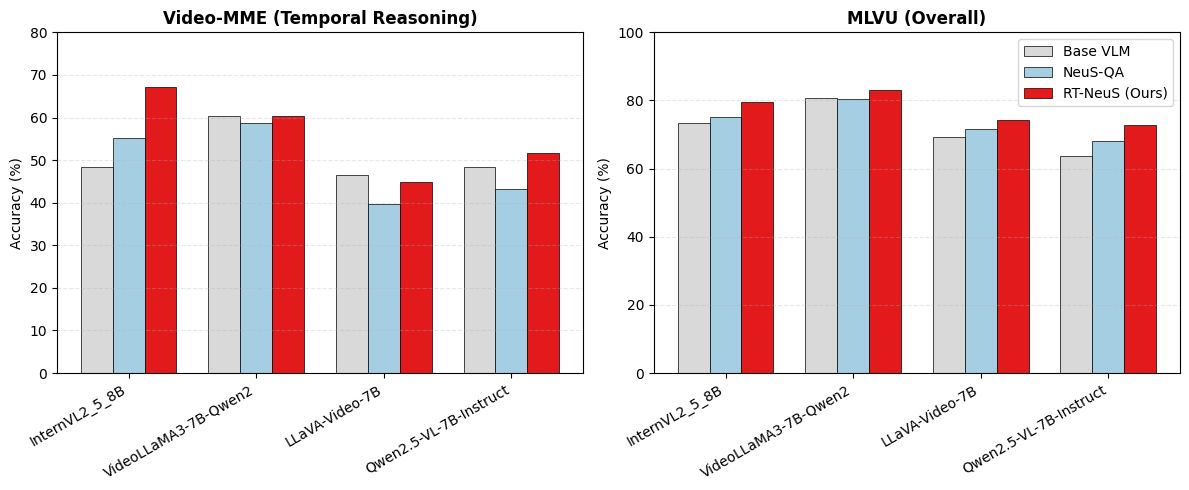

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data Extraction from Table
# We will focus on two key metrics for the plot to keep it readable in a single column:
# 1. Video-MME (Temporal Reasoning)
# 2. MLVU (Overall)

models = ['InternVL2_5_8B', 'VideoLLaMA3-7B-Qwen2', 'LLaVA-Video-7B', 'Qwen2.5-VL-7B-Instruct']

# Data structure: [InternVL, VideoLLaMA, LLaVA, Qwen]
# Temporal Reasoning Scores
base_temporal = [48.28, 60.34, 46.55, 48.28]
neus_temporal = [55.17, 58.62, 39.66, 43.10]
rt_neus_temporal = [67.24, 60.34, 44.83, 51.72]

# MLVU Overall Scores
base_overall = [73.38, 80.60, 69.14, 63.77]
neus_overall = [75.07, 80.45, 71.68, 67.99]
rt_neus_overall = [79.46, 83.00, 74.38, 72.80]

x = np.arange(len(models))  # the label locations
width = 0.25  # the width of the bars

# Create subplots: 1 row, 2 columns (one for each metric)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Video-MME (Temporal Reasoning) ---
rects1 = ax1.bar(x - width, base_temporal, width, label='Base VLM', color='#d9d9d9', edgecolor='black', linewidth=0.5)
rects2 = ax1.bar(x, neus_temporal, width, label='NeuS-QA', color='#a6cee3', edgecolor='black', linewidth=0.5)
rects3 = ax1.bar(x + width, rt_neus_temporal, width, label='RT-NeuS (Ours)', color='#e31a1c', edgecolor='black', linewidth=0.5)

ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Video-MME (Temporal Reasoning)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha='right')
ax1.set_ylim(0, 80)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plot 2: MLVU (Overall) ---
rects4 = ax2.bar(x - width, base_overall, width, label='Base VLM', color='#d9d9d9', edgecolor='black', linewidth=0.5)
rects5 = ax2.bar(x, neus_overall, width, label='NeuS-QA', color='#a6cee3', edgecolor='black', linewidth=0.5)
rects6 = ax2.bar(x + width, rt_neus_overall, width, label='RT-NeuS (Ours)', color='#e31a1c', edgecolor='black', linewidth=0.5)

ax2.set_ylabel('Accuracy (%)')
ax2.set_title('MLVU (Overall)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=30, ha='right')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

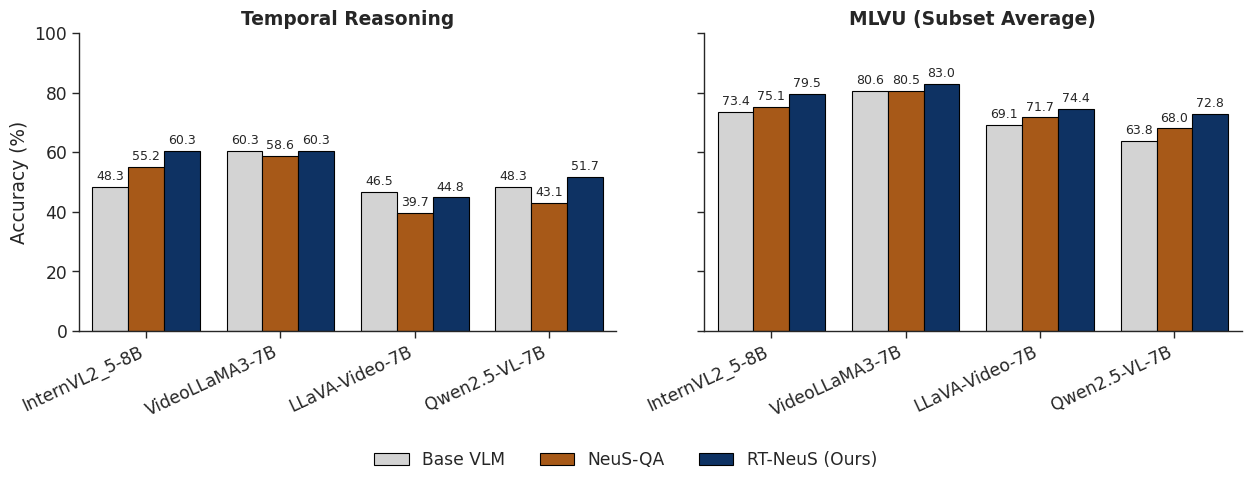

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data Construction
# RENAMED 'MLVU Overall' to 'MLVU (Subset Average)' to be accurate

# 1. Global Style Settings for "Simplistic Conference" look
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['axes.linewidth'] = 0.8  # Thinner axis lines

data = {
    'Model': ['InternVL2_5-8B', 'VideoLLaMA3-7B', 'LLaVA-Video-7B', 'Qwen2.5-VL-7B'] * 3,
    'Framework': ['Base VLM']*4 + ['NeuS-QA']*4 + ['RT-NeuS (Ours)']*4,
    'Temporal Reasoning': [48.28, 60.34, 46.55, 48.28, 
                           55.17, 58.62, 39.66, 43.10, 
                           60.34, 60.34, 44.83, 51.72],
    'MLVU (Subset Average)': [73.38, 80.60, 69.14, 63.77, 
                              75.07, 80.45, 71.68, 67.99, 
                              79.46, 83.00, 74.38, 72.80]
}

df = pd.DataFrame(data)

# Melt for Seaborn
df_melted = df.melt(id_vars=['Model', 'Framework'], 
                    value_vars=['Temporal Reasoning', 'MLVU (Subset Average)'], 
                    var_name='Metric', value_name='Accuracy (%)')

# Set Seaborn theme
sns.set_theme(style="whitegrid", font_scale=1.1)
# Set up the plot style for academic paper
sns.set_context("paper", font_scale=1.4) # Increase font scale for readability
sns.set_style("ticks") # Clean style with ticks, white background
# Create the plot
# Note: legend_out=True helps, but we will move it manually later for better control
g = sns.catplot(
    data=df_melted, 
    x='Model', 
    y='Accuracy (%)', 
    hue='Framework', 
    col='Metric', 
    kind='bar',
    palette=['#d3d3d3', "#BF5700", "#003071"], # Your preferred colors
    height=4.5, 
    aspect=1.2,
    legend=True, # Let Seaborn generate the legend initially
    edgecolor="black", 
    linewidth=0.8
)

# Customization
g.set_axis_labels("", "Accuracy (%)")
g.set_titles("{col_name}", fontweight='bold') # Bold titles for clarity

# Adjust x-axis labels rotation
for ax in g.axes.flat:
    # Add a slight top margin so bars don't hit the title
    ax.set_ylim(0, 100)
    
    for label in ax.get_xticklabels():
        label.set_rotation(25)
        label.set_horizontalalignment('right')
        
    # Optional: Add values on top of bars for precision
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

# --- FIXING THE LEGEND ---
# Move the legend outside the plot area, to the top center or bottom
# bbox_to_anchor controls the position relative to the figure
sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(0.5, -0.1), # Coordinates (x, y) relative to figure
    ncol=3, # Horizontal legend
    title=None, 
    frameon=False
)

sns.despine()
# Adjust layout to ensure legend fits
plt.subplots_adjust(bottom=0.2) 
plt.tight_layout() # This might override subplots_adjust, so use carefully or remove if issues arise

plt.savefig('Video-mme-mvlu-accuracy.pdf', dpi=600, bbox_inches='tight') # bbox_inches='tight' ensures nothing is cut off
plt.show()